## 4. Feature Engineering (TF-IDF)

In [6]:
# ============================================================
# Feature Engineering — TF-IDF
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000, min_df=2, max_df=0.9, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["clean_text"])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")


TF-IDF matrix shape: (50000, 2000)


## 5. Dimensionality Reduction (Truncated SVD)

In [7]:
# ============================================================
# Dimensionality Reduction (Truncated SVD — works directly on sparse TF-IDF)
# ============================================================
from sklearn.decomposition import TruncatedSVD

# Use enough components to retain most variance for clustering,
# and a separate 2D projection purely for visualization.
n_components = min(50, X_tfidf.shape[1] - 1, X_tfidf.shape[0] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X_tfidf)

svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd_2d.fit_transform(X_tfidf)

print(f"Reduced feature matrix for clustering: {X_reduced.shape}")
print(f"Explained variance ratio (first {n_components} components): "
      f"{svd.explained_variance_ratio_.sum():.3f}")


Reduced feature matrix for clustering: (50000, 50)
Explained variance ratio (first 50 components): 0.127


## 6. K-Means Clustering

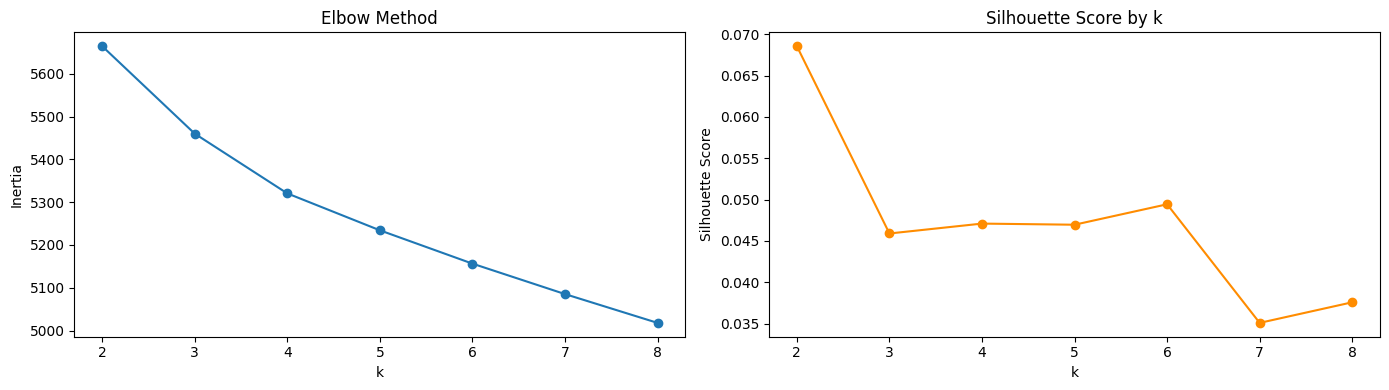

Best k by silhouette score: 2


In [8]:
# ============================================================
# K-Means — choosing K (Elbow Method + Silhouette Score)
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_reduced, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")


In [9]:
# ============================================================
# K-Means — fit final model
# ============================================================
K_FINAL = best_k  # override manually here if you prefer a specific k, e.g. K_FINAL = 2

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df["cluster_kmeans"] = kmeans_final.fit_predict(X_reduced)

print(df["cluster_kmeans"].value_counts().sort_index())
print(f"Final silhouette score: {silhouette_score(X_reduced, df['cluster_kmeans']):.3f}")


cluster_kmeans
0    33218
1    16782
Name: count, dtype: int64
Final silhouette score: 0.069


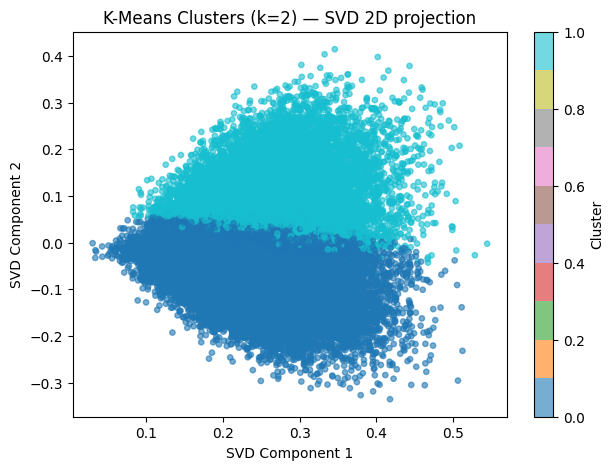

In [10]:
# ============================================================
# K-Means — 2D visualization
# ============================================================
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster_kmeans"], cmap="tab10", alpha=0.6, s=15)
plt.title(f"K-Means Clusters (k={K_FINAL}) — SVD 2D projection")
plt.xlabel("SVD Component 1"); plt.ylabel("SVD Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


## 7. Cluster Interpretation

In [11]:
# ============================================================
# K-Means — cluster interpretation (top terms per cluster)
# ============================================================
# Approximate top terms per cluster by mapping SVD centroids back through
# the SVD components into TF-IDF term space.
terms = np.array(tfidf.get_feature_names_out())
centroids_tfidf_space = kmeans_final.cluster_centers_.dot(svd.components_)

for c in range(K_FINAL):
    top_idx = centroids_tfidf_space[c].argsort()[::-1][:12]
    print(f"Cluster {c} top terms: {', '.join(terms[top_idx])}")

if LABEL_COLUMN is not None and LABEL_COLUMN in df.columns:
    from sklearn.metrics import adjusted_rand_score
    ari = adjusted_rand_score(df[LABEL_COLUMN], df["cluster_kmeans"])
    print(f"\nAdjusted Rand Index vs true label (sanity check only): {ari:.3f}")


Cluster 0 top terms: film, one, like, movie, character, time, story, show, good, get, would, well
Cluster 1 top terms: movie, one, like, bad, good, really, time, see, would, even, make, character


## 8. Insights & Discussion

## Insights & Discussion — K-Means

*Fill this section in after running on the full unsupervised dataset.*

- What does each cluster seem to represent (e.g. do the top terms suggest a
  positive/negative split, or something else like genre or topic)?
- How well-separated are the clusters (silhouette score)? Is one cluster much
  larger or tighter than the others?
- If a label column was available, how well did clusters align with it (ARI)?
  A low ARI doesn't necessarily mean failure — K-Means may be picking up a
  different structure (e.g. topic) than sentiment.
- Any limitations: TF-IDF + SVD assumes linear structure and roughly convex,
  similarly-sized clusters — K-Means struggles if the real groups are not
  spherical or are very different in size/density.


## 9. Test-Set Evaluation (predict rating from cluster, compare to true rating)

In [12]:
# ============================================================
# Load test data — files named "<id>_<rating>.txt"
# ============================================================
import glob, os

def load_labeled_txt_folder(test_dir):
    """
    Expects test_dir/pos/<id>_<rating>.txt and test_dir/neg/<id>_<rating>.txt
    (aclImdb-style, searched recursively so any subfolder layout works).
    Captures the rating from the filename and the sentiment label from the
    parent folder name ("pos" / "neg").
    """
    records = []
    for path in glob.glob(os.path.join(test_dir, "**", "*.txt"), recursive=True):
        stem = os.path.splitext(os.path.basename(path))[0]   # e.g. "200_7"
        parts = stem.split("_")
        try:
            rating = int(parts[-1])
        except ValueError:
            continue  # skip anything that doesn't end in "_<number>"

        sentiment = os.path.basename(os.path.dirname(path))  # "pos" or "neg"

        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        records.append({
            "review": text,
            "true_rating": rating,
            "true_sentiment": sentiment,
            "file": path,
        })
    return pd.DataFrame(records)


if os.path.isdir(TEST_DIR) and len(glob.glob(os.path.join(TEST_DIR, "**", "*.txt"), recursive=True)) > 0:
    test_df = load_labeled_txt_folder(TEST_DIR)
else:
    # TEST_DIR not found -> synthetic stand-in so this section still runs
    # end-to-end. Point TEST_DIR at your real folder (see CONFIG cell).
    synthetic_test = [
        ("This movie was absolutely wonderful, the acting was superb!", 9, "pos"),
        ("Terrible film, a complete waste of time and money.", 1, "neg"),
        ("I loved every minute of it, brilliant direction and story.", 10, "pos"),
        ("Awful plot, bad acting, I want my two hours back.", 2, "neg"),
        ("A masterpiece of modern cinema, truly inspiring.", 9, "pos"),
        ("Boring and predictable, I fell asleep halfway through.", 3, "neg"),
        ("Great performances all around, highly recommended!", 8, "pos"),
        ("Worst movie I have seen this year, avoid at all costs.", 1, "neg"),
        ("Fantastic soundtrack and stunning visuals throughout.", 8, "pos"),
        ("The script was weak and the pacing was painfully slow.", 3, "neg"),
        ("An emotional rollercoaster with a satisfying ending.", 9, "pos"),
        ("Poorly written characters with no real development.", 2, "neg"),
        ("One of the best films of the decade, a must watch.", 10, "pos"),
        ("Disappointing sequel that ruined the original legacy.", 2, "neg"),
        ("Charming, funny, and heartfelt from start to finish.", 8, "pos"),
        ("Cliche ridden and utterly forgettable.", 3, "neg"),
        ("The cinematography alone makes this worth watching.", 7, "pos"),
        ("Confusing storyline that never really goes anywhere.", 4, "neg"),
        ("A delightful surprise, exceeded all my expectations.", 9, "pos"),
        ("Overacted and overhyped, not worth the ticket price.", 2, "neg"),
    ] * 4
    test_df = pd.DataFrame(synthetic_test, columns=["review", "true_rating", "true_sentiment"])
    test_df["file"] = "synthetic"

print(f"Loaded {len(test_df)} test files")
test_df.head()


Loaded 25000 test files


,review,true_rating,true_sentiment,file
0,Once again Mr. Costner has dragged out a movie...,2,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...
1,This is an example of why the majority of acti...,4,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...
2,"First of all I hate those moronic rappers, who...",1,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...
3,Not even the Beatles could write songs everyon...,3,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...
4,Brass pictures (movies is not a fitting word f...,3,neg,D:/3rd Year/MDS/Assignment/aclImdb_v1/aclImdb/...


In [13]:
# ============================================================
# Preprocess test reviews the SAME way as training data
# ============================================================
test_df["clean_text"] = test_df["review"].apply(clean_text)
test_df = test_df[test_df["clean_text"].str.len() > 0].reset_index(drop=True)

# IMPORTANT: transform only — never re-fit TF-IDF or SVD on test data,
# or the comparison stops being a fair held-out evaluation.
X_test_tfidf = tfidf.transform(test_df["clean_text"])
X_test_reduced = svd.transform(X_test_tfidf)

print(f"{len(test_df)} test rows ready, feature shape {X_test_reduced.shape}")


25000 test rows ready, feature shape (25000, 50)


In [14]:
# ============================================================
# Map clusters -> rating, then evaluate against the true rating
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_df["cluster"] = kmeans_final.predict(X_test_reduced)

# Split the test files into a calibration half (used only to work out what
# rating each cluster "means") and an evaluation half (used only to score
# error) so the reported error isn't measured on the same rows that built
# the mapping.
strat = test_df["true_rating"] if test_df["true_rating"].nunique() > 1 else None
calib_idx, eval_idx = train_test_split(
    test_df.index, test_size=1 - CALIBRATION_FRACTION,
    random_state=RANDOM_STATE, stratify=strat
)

cluster_to_rating = test_df.loc[calib_idx].groupby("cluster")["true_rating"].mean()
fallback_rating = test_df.loc[calib_idx, "true_rating"].mean()

test_df["predicted_rating"] = test_df["cluster"].map(cluster_to_rating).fillna(fallback_rating)

print("Cluster -> average true rating (from calibration half):")
print(cluster_to_rating.round(2))

eval_df = test_df.loc[eval_idx]
mae = mean_absolute_error(eval_df["true_rating"], eval_df["predicted_rating"])
rmse = mean_squared_error(eval_df["true_rating"], eval_df["predicted_rating"]) ** 0.5

print(f"\nEvaluated on {len(eval_df)} held-out test files")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


Cluster -> average true rating (from calibration half):
cluster
0    5.91
1    4.72
Name: true_rating, dtype: float64

Evaluated on 12500 held-out test files
MAE:  3.202
RMSE: 3.443


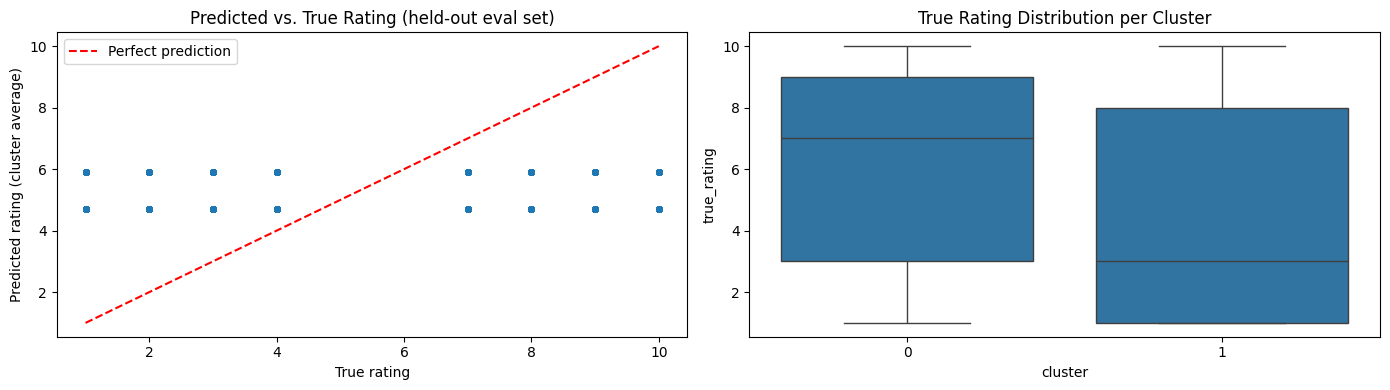

In [15]:
# ============================================================
# Visualize predicted vs. true rating
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(eval_df["true_rating"], eval_df["predicted_rating"], alpha=0.5, s=15)
lims = [test_df["true_rating"].min(), test_df["true_rating"].max()]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("True rating"); axes[0].set_ylabel("Predicted rating (cluster average)")
axes[0].set_title("Predicted vs. True Rating (held-out eval set)")
axes[0].legend()

sns.boxplot(data=test_df, x="cluster", y="true_rating", ax=axes[1])
axes[1].set_title("True Rating Distribution per Cluster")

plt.tight_layout()
plt.show()


### Test-Set Evaluation — Discussion

- The cluster→rating mapping is built from the calibration half only and scored on the
  held-out half — that's the fair error number to report (MAE / RMSE above).
- Since K-Means never sees the rating during clustering, this error tells you how much
  rating information happens to fall out of the *text-similarity* structure it found —
  it is not expected to compete with a supervised regressor.
- If MAE is large, check the box plot: if the true-rating spread within each cluster is
  wide, the clusters aren't really separating reviews by rating — they may be grouping by
  something else (topic, review length, etc.) instead.


## 10. Semantic Similarity Rating (contextual-meaning comparison)

In [16]:
# ============================================================
# Semantic (contextual-meaning) embeddings — with an offline-safe fallback
# ============================================================
# Tries real sentence embeddings (captures meaning, not just word overlap).
# If the model weights can't be downloaded in this environment, falls back
# to a small Word2Vec trained on this corpus so the section still runs
# end-to-end. Swap in the sentence-transformers path in your own environment
# for the real semantic version.
import numpy as np

def get_embeddings(texts, clean_texts):
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer("all-MiniLM-L6-v2")
        emb = model.encode(texts, show_progress_bar=True, batch_size=64)
        return np.asarray(emb), "sentence-transformers (all-MiniLM-L6-v2)"
    except Exception as e:
        print(f"sentence-transformers unavailable ({type(e).__name__}: {e})")
        print("Falling back to a locally-trained Word2Vec embedding (offline, no download).")
        from gensim.models import Word2Vec
        tokenized = [t.split() for t in clean_texts]
        w2v = Word2Vec(sentences=tokenized, vector_size=100, window=5,
                        min_count=1, workers=2, seed=RANDOM_STATE)

        def avg_vec(tokens):
            vecs = [w2v.wv[t] for t in tokens if t in w2v.wv]
            return np.mean(vecs, axis=0) if vecs else np.zeros(w2v.vector_size)

        emb = np.array([avg_vec(t) for t in tokenized])
        return emb, "locally-trained Word2Vec (fallback)"


test_embeddings, embed_method_used = get_embeddings(
    test_df["review"].tolist(), test_df["clean_text"].tolist()
)
print(f"\nUsing: {embed_method_used}  |  embedding shape: {test_embeddings.shape}")


README.md: 0.00B [00:00, ?B/s]

Batches:   0%|          | 0/391 [00:00<?, ?it/s]


Using: sentence-transformers (all-MiniLM-L6-v2)  |  embedding shape: (25000, 384)


In [17]:
# ============================================================
# Score reviews by semantic similarity to positive/negative anchors,
# calibrate against true rating, evaluate on the SAME held-out split
# used for the cluster-based prediction above
# ============================================================
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Anchors built from the CALIBRATION half only, using the aclImdb convention
# (rating <=4 negative, rating >=7 positive) — never the evaluation half.
calib_ratings = test_df.loc[calib_idx, "true_rating"]
pos_idx = calib_idx[(calib_ratings >= 7).values]
neg_idx = calib_idx[(calib_ratings <= 4).values]

pos_centroid = test_embeddings[pos_idx].mean(axis=0, keepdims=True)
neg_centroid = test_embeddings[neg_idx].mean(axis=0, keepdims=True)

sim_pos = cosine_similarity(test_embeddings, pos_centroid).ravel()
sim_neg = cosine_similarity(test_embeddings, neg_centroid).ravel()
test_df["semantic_score"] = sim_pos - sim_neg

# Calibrate score -> rating with a linear fit on the calibration half only
reg = LinearRegression()
reg.fit(test_df.loc[calib_idx, ["semantic_score"]], test_df.loc[calib_idx, "true_rating"])
test_df["predicted_rating_semantic"] = reg.predict(test_df[["semantic_score"]])

eval_df = test_df.loc[eval_idx]
mae_sem = mean_absolute_error(eval_df["true_rating"], eval_df["predicted_rating_semantic"])
rmse_sem = mean_squared_error(eval_df["true_rating"], eval_df["predicted_rating_semantic"]) ** 0.5

print(f"Semantic similarity -> MAE: {mae_sem:.3f}  RMSE: {rmse_sem:.3f}")


Semantic similarity -> MAE: 2.277  RMSE: 2.759


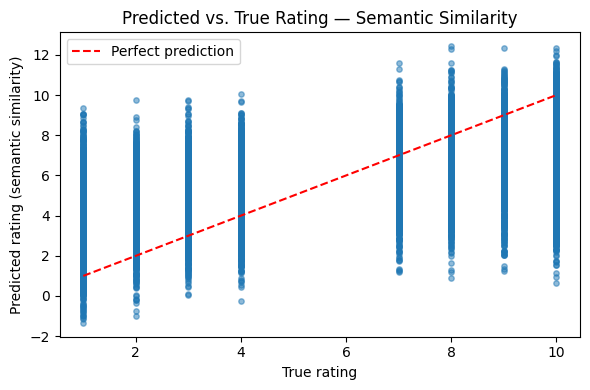

In [18]:
# ============================================================
# Predicted vs. true rating — semantic similarity method
# ============================================================
plt.figure(figsize=(6, 4))
plt.scatter(eval_df["true_rating"], eval_df["predicted_rating_semantic"], alpha=0.5, s=15)
lims = [test_df["true_rating"].min(), test_df["true_rating"].max()]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("True rating"); plt.ylabel("Predicted rating (semantic similarity)")
plt.title("Predicted vs. True Rating — Semantic Similarity")
plt.legend()
plt.tight_layout()
plt.show()


                    Method       MAE      RMSE
0  Cluster-based (K-Means)  3.202281  3.443176
1      Semantic similarity  2.277151  2.759375


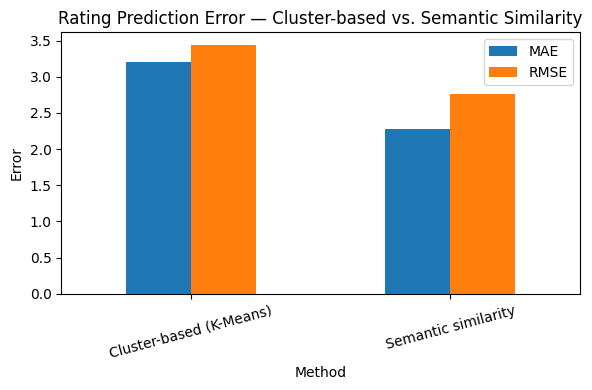

In [19]:
# ============================================================
# Cluster-based vs. semantic-similarity rating prediction — side by side
# ============================================================
cluster_mae = mean_absolute_error(eval_df["true_rating"], eval_df["predicted_rating"])
cluster_rmse = mean_squared_error(eval_df["true_rating"], eval_df["predicted_rating"]) ** 0.5

comparison = pd.DataFrame({
    "Method": ["Cluster-based (K-Means)", "Semantic similarity"],
    "MAE": [cluster_mae, mae_sem],
    "RMSE": [cluster_rmse, rmse_sem],
})
print(comparison)

comparison.set_index("Method")[["MAE", "RMSE"]].plot(kind="bar", figsize=(6, 4))
plt.title("Rating Prediction Error — Cluster-based vs. Semantic Similarity")
plt.ylabel("Error")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Semantic Similarity vs. Cluster-Based — Discussion

- Both methods only touch the true rating *after* building their structure (clusters, or
  anchor centroids) — ratings never influence the clustering or embedding step itself, only
  the final interpretation. That boundary is inherent to any unsupervised approach.
- If semantic similarity wins, it suggests meaning/context — not just shared vocabulary —
  is doing the real work of separating positive from negative reviews (e.g. it should
  handle synonyms and rephrasing better than TF-IDF word overlap).
- If the fallback Word2Vec embedding was used instead of sentence-transformers (see the
  printed message above the embeddings), treat these particular numbers as a structural
  demonstration rather than a strong result — a corpus this size doesn't give Word2Vec much
  to learn from. Re-run in an environment with internet access to the model hub for the
  real sentence-transformers embeddings and a meaningful comparison.
